# **ESERCIZIO 8.1**

**OBIETTIVI**

L'obiettivo di questo esercizio è implementare un codice di VMC per stimare numericamente l'energia dello stato fondamentale di una particella quantistica in un potenziale monodimensionale $V(x) = x^4 - \frac{5}{2}x^2$. In particolare, il metodo Variational Monte Carlo si basa sull’uso di una funzione d’onda di prova $\Psi_T$, dipendente da un insieme di parametri variazionali, che viene ottimizzata per approssimare la funzione d'onda dello stato fondamentale dell'hamiltoniana del sistema. Un’approssimazione ragionevole per la funzione d’onda del ground state è la seguente:

$$
\Psi_T^{\sigma,\mu}(x) \propto
e^{-\frac{(x-\mu)^2}{2\sigma^2}} +
e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$

dove $\mu$ e $\sigma$ sono i parametri variazionali che determinano rispettivamente la posizione dei due massimi della funzione e la loro larghezza.

Il principio variazionale afferma che il valore medio di una Hamiltoniana H, calcolato su una funzione d'onda di prova $\Psi_T^{\sigma,\mu}(x)$, è un limite superiore per l'energia del ground state "reale" $E_0$, ovvero:

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} \ge E_0 =
\frac{\langle \Psi_0| {\hat H} | \Psi_0 \rangle}
{\langle \Psi_0 | \Psi_0 \rangle}
$$

In particolare, in questo esercizio bisogna calcolare il valore energetico dello stato fondamentale per una specifica funzione d'onda di prova $\Psi_T^{\sigma,\mu}(x)$, parametrizzata dai parametri $\sigma$ e $\mu$, che ho scelto rispettivamente pari a 0.5 e 1.1. Infine, è bene confrontare il valore energetico ottenuto numericamente con quello atteso: secondo il principio variazionale, infatti, il valore che ottengo dalla simulazione non può essere minore dell'energia esatta dello stato fondamentale.

**IMPLEMENTAZIONE**

Dal momento che l'equazione differenziale per trovare il GS della particella non può essere risolta analiticamente per V(x), che non è quadratico, cerco la soluzione numericamente. In particolare, utilizzerò il metodo di Metropolis, che mi permette di generare una sequenza di punti $x$ distribuiti secondo una specifica densità di probabilità. Infatti, per poter utilizzare Monte Carlo, devo riscrivere l'espressione del valor medio di $H$ in modo che abbia la forma di una media pesata su una probabilità, ovvero, moltiplicando e dividendo per $\Psi_T(x)$:

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
\rightarrow \frac{1}{M} \sum_{i=1}^{M} E_{loc}(x_i)
$$

In questa forma è evidente che $\frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2}$ è la densità di probabilità (che campiono con Metropolis), e $\frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}$ è l'energia locale $E_{loc}$, ovvero la funzione che devo mediare sui punti campionati.

In particolare, ho implementato la funzione $Metropolis()$ in questo modo:

- propongo una nuova posizione $x_{new}$ di Metropolis utilizzando come passo un valore generato in modo casuale da una distribuzione uniforme tra [-$\delta$,$\delta$], dove $\delta$ è il parametro che definisce l'ampiezza del passo, ovvero rappresenta lo spostamento massimo per esplorare lo spazio delle configurazioni.
  
- calcolo la probabilità associata rispettivamente a $x_{old}$ e $x_{new}$, definita come il modulo quadro della funzione d'onda, valutata rispettivamente in $x_{old}$ e $x_{new}$. Queste due probabilità mi servono perchè Metropolis consiste nel generare una sequenza di punti distribuiti, in questo caso, secondo $\frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2}$ ; dal momento che non conosco la normalizzazione della densità di probabilità quantistica $\int dx |\Psi_T(x)|^2$, fare il rapporto tra le due probabilità mi permette di semplificare questo termine.

  
- calcolo il rapporto di accettanza $A$, definito come $\min(1,\frac{p_\text{new}}{p_\text{old}})$, dal momento che il passo proposto è simmetrico ([-$\delta$,$\delta$]). Il rapporto di accettanza è il parametro che determina la probabilità di accettare la mossa da $x_{old}$ a $x_{new}$ e viene definito come il minimo tra 1 e $\frac{p_\text{new}}{p_\text{old}}$ dal momento che, se la mossa viene portata in una regione in cui $p_{new} > p_{old}$, questo significa che la mossa deve essere accettata con certezza e quindi A (che è una probabilità e quindi può valere al massimo 1) viene impostato a 1.

  
- genero un numero casuale uniformemente distribuito tra 0 e 1: se è minore di $A$, accetto la mossa e aggiorno la posizione $x_{old}$, altrimenti rifiuto la mossa, lasciando inalterata $x_{old}$.

Dopodichè, devo utilizzare i punti accettati per calcolare l'energia locale e, usando il data blocking, stimare il valor medio dell'energia dello stato fondamentale con la rispettiva incertezza.

In particolare, ho implementato delle nuove funzioni per calcolare $V(x)$, $\psi$, la derivata di $\psi$ e l'energia locale.

**SIMULAZIONE**

Prima di tutto faccio evolvere il sistema per trovare il valore di delta che fa stabilizzare l'acceptance attorno al valore di 0.5. In particolare, ho trovato un valore di delta pari a 1.02, che in 1000 passi porta l'acceptance a un valore di 0.507. 

Dopodichè eseguo 2000 step di riequilibrazione: questo mi serve per ridurre la dipendenza dal valore iniziale $x_0$ (che è scelto arbitrariamente) e avvicinarmi a una regione di $x$ in cui effettivamente i punti estratti rispecchiano la densità di probabilità che voglio campionare.

A questo punto, implemento il data blocking e salvo i valori di media ed errore progressivi in un file output. In aggiunta, calcolo per ogni blocco il valore di acceptance e lo stampo su un altro file esterno, al fine di monitorarne l'andamento in funzione del numero di blocchi e capire se i dati simulati sono validi o meno.

Acceptance media:  0.5317


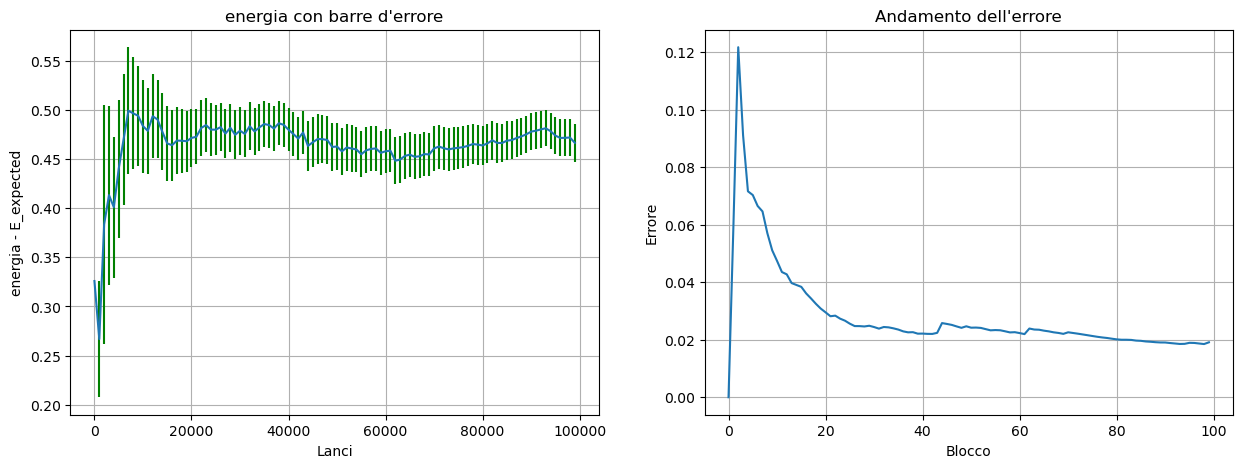

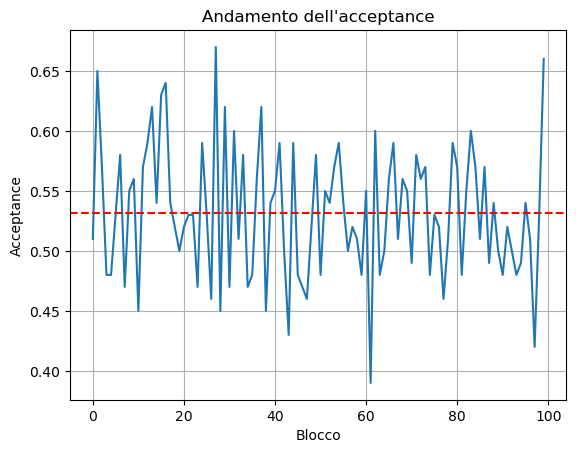

In [1]:
import matplotlib.pyplot as plt
import numpy as np


lanci=100000
blocchi=100
n=int(lanci/blocchi)
E_exp=-0.460465879692715

#genero indici dei blocchi (da 0)
x=np.arange(blocchi)


#apro i file, prendo media e errore
file1=np.loadtxt("08.1/energia.dat")
media=file1[:,0]
varianza=file1[:,1]

#calcolo acceptance media
file2=np.loadtxt("08.1/acceptance.dat")
acc_media=np.mean(file2)

print("Acceptance media: ",acc_media)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)

x=(x*n) #voglio grafici in funzione del numero di lanci= moltiplico l'indice del blocco per il numero di lanic per blocco
plt.errorbar(x, media-E_exp, yerr=varianza, ecolor='green')
plt.xlabel('Lanci')
plt.ylabel('energia - E_expected')
plt.title("energia con barre d'errore")
plt.grid(True)


plt.subplot(1,2, 2)
plt.plot(varianza)
plt.xlabel('Blocco')
plt.ylabel('Errore')
plt.title("Andamento dell'errore")
plt.grid(True)
plt.show()


plt.plot(file2)
plt.axhline(acc_media,color="red", linestyle="--")
plt.xlabel('Blocco')
plt.ylabel('Acceptance')
plt.title("Andamento dell'acceptance")
plt.grid(True)
plt.show()

**COMMENTO AI RISULTATI**

Il primo grafico (che riporta l'andamento del valor medio dell'energia del GS meno il valore reale) mostra che il valor medio dell'energia, dopo le prime fluttuazioni iniziali, si stabilizza attorno a un valore costante; inoltre, il grafico relativo all'andamento dell'errore sulla media cumulativa mostra, in accordo con quanto previsto dal teorema del limite centrale, un andamento decrescente $\sim \frac{1}{\sqrt{N}}$ all'aumentare del numero di blocchi. 

Come si può osservare dal primo grafico, dalla simulazione ho ottenuto per il ground state un valore energetico che chiaramente non è compatibile, entro l'incertezza, con quello teorico: tuttavia, il valore trovato è maggiore di quello atteso, e quindi il risultato è coerente con il principio variazionale. Questa discrepanza è segno che i parametri $\mu$ e $\sigma$ utilizzati non sono ancora quelli ottimali: i parametri ottimali verranno infatti trovati nell'esercizio successivo tramite l'algoritmo del Simulated Annealing.

Infine, il terzo grafico mostra che i valori dell'acceptance oscillano attorno al valor medio di circa 0.52. Questo valore "ottimale" dell'acceptance $\sim 0.5$ garantisce che il campionamento sia efficiente: valori troppo alti indicano passi $\delta$ troppo piccoli, che portano ad avere una sequenza di $x$ estratti in una regione limitata e rendono il campionamento poco efficiente; al contrario, valori troppo bassi dell'acceptance indicano degli spostamenti $\delta$ troppo grandi, che portano in regioni dove $|\Psi_T(x)|^2$ è piccola e pertanto le mosse sono quasi sempre rifiutate.

# **ESERCIZIO 8.2**

**OBIETTIVI**

In questo esercizio devo trovare i parametri $\mu$ e $\sigma$ che ottimizzano  $\langle {\hat H} \rangle_T$, ovvero il valor medio dell'energia (sulla funzione di pova) calcolato con Metropolis, utilizzando l'algoritmo del Simulated Annealing. In particolare, l'esercizio vuole mostrare come, man mano che mi avvicino ai parametri $\mu$ e $\sigma$ ottimali, l'energia si avvicina al suo valore di minimo, ovvero al valore energetico esatto dello stato fondamentale.

Inoltre, devo realizzare diversi grafici:
- un grafico che mostri l'andamento di $\langle {\hat H} \rangle_T$ (con la rispettiva incertezza statistica) in funzione degli step del Simulated Annealing
- un grafico che mostri l'andamento della traiettoria del SA nello spazio dei parametri $\mu$ e $\sigma$ in funzione degli step
- un grafico che mostri l'andamento di $\langle {\hat H} \rangle_T$ (con la rispettiva incertezza statistica) in funzione del numero di blocchi, per la coppia $\sigma$ e $\mu$ che minimizza l'energia
- un grafico che mostri la distribuzione campionata $|\Psi_T(x)|^2$ , realizzato costruendo un istogramma delle configurazioni campionate, e confrontarlo con:
  - curva analitica di $|\Psi_T(x)|^2$
  - soluzione numerica ottenuta trasformando l'equazione di Schrodinger in un problema matriciale

**IMPLEMENTAZIONE**

Per questo esercizio ho bisogno di implementare l'algoritmo di Metropolis per due diversi campiomanenti: uno VMC per campionare le coordinate $x$ per poter calcolare  $\langle {\hat H} \rangle_T$, e uno che invece "muove" i parametri $\sigma$ e $\mu$, per esplorare lo spazio delle configurazioni energetiche al fine di trovare la miglior stima dell'energia del ground state. In particolare, il Metropolis VMC è lo stesso che ho usato nell'esercizio 8.1, mentre ho deciso di implementare il Metropolis per il Simulated Annealing direttamente nel main.

Prima di tutto, ho ritenuto opportuno creare due nuove fuzioni, $H$ e $calcolo_\text{delta}$: la prima per implementare il metodo del data blocking e restituire il valor medio e l'errore finali a una data temperatura T, per una coppia di parametri ($\sigma$,$\mu$); la seconda per scegliere il valore delta ottimale per mantenere l'acceptance attorno a 0.5, al variare di $\sigma$ e $\mu$.

1. **H**: prende in ingresso $\mu$, $\sigma$, il numero di blocchi e di lanci per blocco, il passo delta, e le reference all'errore e al generatore, e restituisce il valore finale del valor medio dell'energia. La reference al generatore serve per mantenere la continuità della sequenza dei numeri generati casualmente; quella all'errore permette di "restituire" indirettamente anche l'incertezza finale sul valor medio. La funzione H altro non è che l'implementazione del data blocking.

2. **calcolo_delta**: prende in ingresso $\mu$, $\sigma$ e le reference al generatore e alla posizione x (così funziona anche da riequilibrazione). Ho deciso di implementare questa funzione per poter utilizzare il passo migliore ogni volta che cambio $\mu$ e $\sigma$: infatti, il passo dipende da questi due parametri in quanto Metropolis è legato alla distribuzione $|\Psi_T(x)|^2$, e quindi alla funizone $\Psi_T(x)$, che dipende dalla scelta dei due parametri. La funzione parte da un passo delta circa pari a 1 (valore trovato nell'esercizio precedente), dopodichè esegue un ciclo in cui viene calcolata l'acceptance e viene modificato il valore di delta fino ad ottnere un valore compreso tra 0.45 e 0.55 (o al massimo 100 iterazioni per evitare bug).

Inoltre, scelgo una legge di raffreddamento per aggiornare la temperatura, al fine di "guidare" il sistema verso la configurazione a minima energia. Il SImulated Annealing, infatti, si basa sull'analogia con il processo di raffreddamento di un sistema fisico: man mano che la tmperatura diminuisce, il sistema fisico tende a "congelarsi" attorno alla configurazione più favorevole, ovvero quella a minima energia. Come legge di raffreddamento ho scelto: $T_\text{i+1}=0.95\cdot T_i$, che dopo gli step di SA e partendo da una $T_0=1.0$, mi permette di arrivare a una temperatura finale praticamente nulla.

Dopodichè, implemento nel $main()$ l'algoritmo di Metropolis per il Simulated Annealing in questo modo:
- eseguo un ciclo esterno sul numero di temperature a cui il SA lavorerà; in particolare, ho scelto un numero di temperature pari a 150
- all'interno di questo ciclo eseguo un ulteriore ciclo in cui per ciasuna temperatura eseguo uno specifico numero di passi, in modo che ad alte temperature il SA esegua meno passi per "non perdere tempo" dato che il sistema si trova ancora in una configurazione verosimilmente lontana dal minimo. Ho imposto questa condizione nel seguente modo:
  
        int appo=(int)(1.0/T);
        appo=max(5, min(30, appo));

  così la varibile appo è inversamente legata alla temperatura. L'ultima condizione impone un limite massimo agli step, così da evitare troppi passi.
- calcolo il parametro $\delta$ ottimale usando la funzione che ho implementato per questo fine
- calcolo l'energia $old$ usando i vecchi parametri di $\mu$ e $\sigma$
- partendo dai parametri $old$, propongo una mossa sia per $\mu$ sia per $\sigma$, spostandomi casualmente in un intervallo definito dai parametri $delta$ _ $mu$ e $delta$_$sigma$. Dal momento che $\sigma$ è la deviazione standard, non può assumere valori negativi e per questo motivo metto un controllo sui valori estratti: per questo motivo, continuo a estrarre spostamenti di delta fino a che non ottengo un valore di sigma positivo
- calcolo la nuova energia in base ai nuovi parametri $\mu$ e $\sigma$
- calcolo la differenza $\Delta E= E_\text{new} - E_\text{old}$:
  - se $E_\text{new} < E_\text{old}$ accetto sempre la mossa (questo perchè si tratta di una configurazione sicuramente favorevole)
  - se $E_\text{new} > E_\text{old}$ accetto la mossa con probabilità $P=e^{-\beta\Delta E}$ (garantendo il corretto campionamento dell'ensemble canonico)
- riduco la temperatura seguendo la legge di raffreddamento impostata, ovvero $T_\text{new}=T_\text{old}\cdot0.95$


Infine, utilizzo i parametri ottimali di $\mu$ e $\sigma$ trovati per trovare, tramite il data blocking, la stima migliore per il GS, e per graficare l'andamento progressivo e l'errore progressivo in questo caso ottimale. In ciascuno degli step del data blocking, inoltre, salvo le configurazioni di $x$ campionate con Metropolis VMC, per poter realizzare l'istogramma della distribuzione $|\Psi_T|^2$.

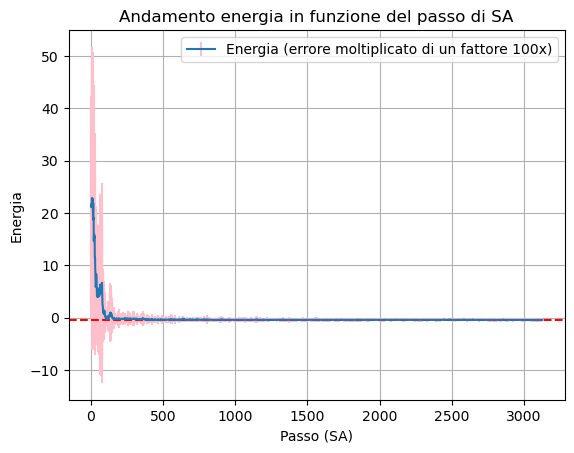

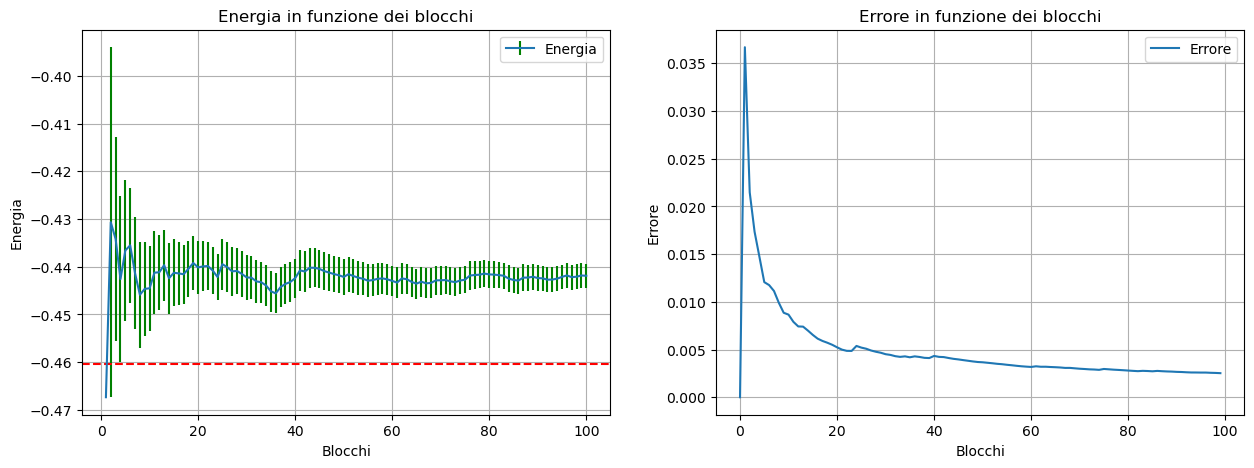

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#carico dati 
data = np.loadtxt("08.2/ottimizzazione.dat") #fileottimizzazione contiene valori di mu sigma energia errore temperatura
energia_blocchi=np.loadtxt("08.2/energia_finale.dat")

#valore atteso energia GS
E_exp=-0.460465879692715

x=data[:,0] #passo SA
mu=data[:,2]
sigma=data[:,3]
E=data[:,4]
errore=data[:,5] #errore su energia
T=data[:,1]

plt.errorbar(x,E,yerr=errore*100, ecolor="pink", label="Energia (errore moltiplicato di un fattore 100x)")
plt.axhline(E_exp,color="red", linestyle="--")
plt.xlabel("Passo (SA)")
plt.ylabel("Energia")
plt.title("Andamento energia in funzione del passo di SA")
plt.legend()
plt.grid()
plt.plot()

plt.figure(figsize=(15, 5))


#Energia
plt.subplot(1, 2, 1)

plt.errorbar(energia_blocchi[:,0], energia_blocchi[:,1], yerr=energia_blocchi[:,2], ecolor='green',label="Energia")
plt.axhline(E_exp, color="red", linestyle="--") #stampo valore energia GS
plt.xlabel('Blocchi')
plt.ylabel('Energia')
plt.title("Energia in funzione dei blocchi")
plt.legend()
plt.grid(True)



plt.subplot(1, 2, 2)

plt.plot(energia_blocchi[:,2],label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi")
plt.legend()
plt.grid(True)
plt.show()

**COMMENTO AI RISULTATI**

Il primo grafico riporta l'andamento di $\langle {\hat H} \rangle_T$ in funzione del numero di passi del Simulated Annealing; il secondo e il terzo riportano l'andamento rispettivamente del valor medio dell'energia dello stato fondamentale (con la rispettiva incertezza e calcolato usando i valori ottimali er $\mu$ e $\sigma$) e dell'errore in funzione del numero di blocchi.

In particolare, analizzando il primo grafico si nota chiaramente che per i primi circa 100 passi l'andamento dell'energia è caratterizzato da forti oscillazioni: in questa prima fase di alta temperatura, infatti, il Simulated Annealing sta esplorando i diversi valori energetici anche accettando mosse che ne peggiorano la stima (come è reso evidente dalle oscillazioni). Man mano che gli step del SA aumentano (ovvero la temperatura diminuisce), il valore dell'energia si stabilizza attorno a un valore costante, in prossimità del valore vero dell'energia del GS. Questo è coerente con il funzionamento del SA: al diminuire della temperatura, infatti, il sistema tende a raffreddarsi verso la configurazione più favorevole. Inoltre, il valore energetico a cui converge l'energia della simulazione è maggiore di quello vero: anche questo è coerente con il principio variazionale.

Anche il grafico del valor medio dell'energia in funzione dei blocchi è interessante: anche in questo caso, infatti, il valore a cui converge l'energia del GS non è compatibile con quello reale entro l'incertezza stistica. Tuttavia, la convergenza al valore vero è compresa entro poche sigma.

Infine, il secondo e il terzo grafico sono in accordo con i risultati previsti dal teorema del limite centrale: l'errore scala come $\sim \frac{1}{\sqrt{N}}$, mentre il valor medio, dopo brevi fluttuazioni iniziali, si stabilizza attorno a un valore costante. Questo conferma che la statistica utilizzata è stata sufficiente ad ottenere una stima affidabile.

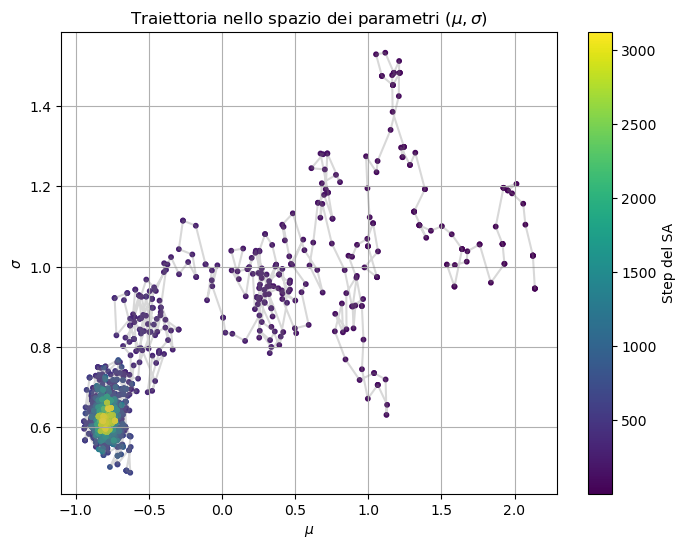

In [2]:
plt.figure(figsize=(8, 6))

x=data[:,0]

#Uso uno scatter plot colorato per i passi per vedere la direzione del SA (punti gialli sono quelli presi a più basse temperature, ovvero negli steps finali)
#c=x significa che ad ogni punto del vettore x associo un colore diverso
#cmap=viridis è una colormap che varia dal blu al giallo
#s=10 è la dimensione dei punti
#alpha è la trasparenza
plt.scatter(mu,sigma,c=x,cmap='viridis',s=10)
plt.plot(mu,sigma, alpha=0.3,color='gray') #plotto la retta che congiunge i punti della traiettoria
plt.colorbar(label='Step del SA')

plt.title('Traiettoria nello spazio dei parametri $(\mu, \sigma)$')
plt.xlabel('$\mu$')
plt.ylabel('$\sigma$')
plt.grid(True)
plt.show()

**COMMENTO AI RISULTATI**

Il grafico relativo alla traiettoria nello spazio dei parametri è molto interessante perchè aiuta a comprendere il funzionamento del Simulated Annealing. Ho scelto di partire da valori di $\mu=2.2$ e $\sigma=1.0$, ovvero da valori sufficientemente lontani da quelli attesi, per mostrare come la traiettoria sia nel complesso piuttosto direzionata verso la regione in cui si trovano i valori ottimali.

All'inizio (alte temperature), i punti della traiettoria sono meno localizzati: in questa prima fase infatti il sistema esplora lo spazio delle configurazioni accettando anche delle mosse che aumentano l'energia, per evitare di rimanere intrappolato nei minimi locali (la probabilità di accettazione è più alta ad alte temperature, quindi il sistema può superare barriere energetiche): l'algoritmo è nella fase di diversificazione. Mano a mano che si raffredda, il sistema si stabilizza attorno a configurazioni a minore energia, fino a raggiungere una configurazione più favorevole, come evidenziato dal cluster finale nel grafico: l'algoritmo è infatti nella fase di intensificazione.

Nel complesso la traiettoria appare convergere verso la regione ottimale, come atteso dal meccanismo di raffreddamento del Simulated Annealing che riduce progressivamente la probabilità di accettare configurazioni energeticamente sfavorevoli. Verso le temperature finali, invece, la traiettoria si stabilizza attorno a una regione ben definita: in questo caso, infatti, il sistema si trova già in una regione "ottimale" e quindi "fluttua" attorno all'area circostante al minimo invece di muoversi in modo direzionale.

*COSTRUZIONE DELL'ISTOGRAMMA E CONFRONTO TRA LE DISTRIBUZIONI*

Il grafico seguente mostra il confronto tra la distribuzione $|\Psi_T|^2$ ottenuta tramite campionamento MC, quella teorica e quella numerica.

In particolare, quella ottenuta tramite MC è rappresentata da un istogramma che ha come entries le posizioni estratte con Metropolis dopo aver individuato i parametri ottimali di $\mu$ e $\sigma$. Nel codice ho infatti fatto stampare, ad ogni passo del data blocking, il valore di x: ho dunque un vettore di dati che contengono posizioni che sono distribuite mediante la $|\Psi_T|^2$, dal momento che sono campionate tramite Metropolis seguendo questa distribuzione di probabilità.

Per quanto riguarda la distribuzione analitica, è stata ottenuta semplicemente implementando in Python la funzione $psi$, e poi elevandola al quadrato. In particolare, ho dovuto normalizzare questa distribuzione affinchè la funzione soddisfi la condizione di normalizzazione $\int |\psi(x)|^2\, dx =1$. Per farlo, approssimo l'integrale con una sommatoria discreta, ovvero: $\int |\psi(x)|^2\, dx \approx \sum_{i=1}^{N} |\psi(x_i)|^2 \, \Delta x$.

Invece, per rappresentare la distribuzione ottenuta dalla simulazione numerica, ho bisogno dell'autofunzione corrispondente all'autovalore energetico minore (ovvero il GS), che ottengo risolvendo l'equazione agli autovalori. Prima di tutto scrivo l'equazione $\hat{H}\psi=E\psi$ come una matrice, discretizzando lo spazio, così da ridurre il problema a una diagonalizzazione matriciale. In questo caso ho bisogno dell'hamiltoniana discreta ${\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)$, e dunque, oltre che di $V(x)$, anche della derivata seconda. In particolare, come indicato nel materiale supplementare, possiamo discretizzare la derivata seconda scrivendola come: $\frac{\partial^2}{\partial x^2} \Psi(x=x_i)=\frac{\Psi_{i+1}-2\Psi_{i}+\Psi_{i-1}}{dx^2}$. Di conseguenza, la matrice risultante sarà occupata solamente lungo la diagonale e lungo le diagonali superiore e inferiore più prossime a quella principale, in questo modo:
$$
\begin{bmatrix}
 \frac{\hbar^2}{m\,dx^2}+V(x_1)& -\frac{\hbar^2}{2m\,dx^2} & 0 & \dots  & 0 \\
-\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_2) & -\frac{\hbar^2}{2m\,dx^2} & \dots  & 0 \\
 0                        & -\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_3) & \dots  & 0 \\
 \vdots                   & \vdots                    & \vdots & \ddots & \vdots \\
 0                    & 0                & 0 & \dots  & \frac{\hbar^2}{m\,dx^2}+V(x_N)
\end{bmatrix}
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
= E
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
$$

A questo punto diagonalizzo la matrice e trovo gli autovalori e le autofunzioni. Seleziono il ground state, normalizzo l'autofunzione associata e la plotto.

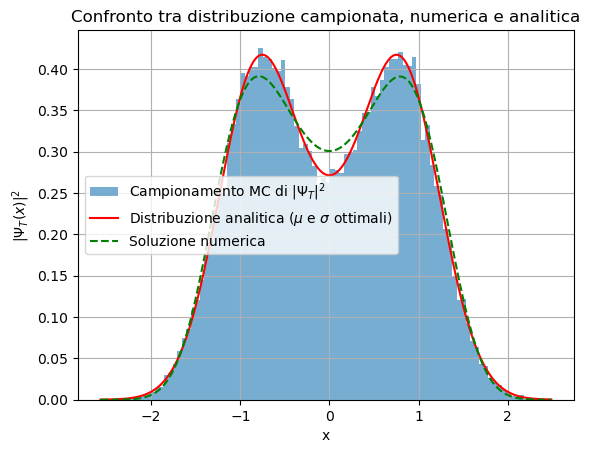

In [5]:
#caricamento dati
parametri=np.loadtxt("08.2/parametri_ottimali.dat")
posizioni=np.loadtxt("08.2/psi2.dat")

#parametri mu e sigma ottimali (ultimi trovati)
mu_opt=parametri[0]
sigma_opt=parametri[1]


#creo l'asse x in modo che copra solo i valori campionati dal MC: creo un array di 1000 punti che corrispondono ai punti dell'asse x in cui valuterò le distribuzioni simulata e analitica
x=np.linspace(min(posizioni),max(posizioni),1000)

#SOLUZIONE ANALITICA
psi=np.exp(-(x-mu_opt)**2/(2*sigma_opt**2))+np.exp(-(x+mu_opt)**2/(2*sigma_opt**2))
psi2=psi**2

#normalizzazione funzione analitica
dx=x[1]-x[0] #calcolo ampiezza intervallino dx (gli elementi di x sono tutti equispaziati, quindi considero i primi due)
norm=np.sum(psi2)*dx  #approssimo integrale come somma di rettangoli
psi2/=norm #restituisco la funzione normalizzata

#SOLUZIONE NUMERICA
#scrivo funzione per calcolare il potenziale V(x)
def pot(x):
    return (x**2-2.5)*x**2

hbar=1 #imposto h tagliato in unità naturali
m=1 #massa in unità naturali
N=1000 #discretizzo lo spazio in 1000 punti

V=pot(x) #calcolo il potenziale per ogni punto x dell'asse x nel range selezionato (ottengo un vettore di N punti)


diag=np.full(N,-1.0)  #creo un array di dimensione N riempito con il coefficiente -1: mi serve per il laplaciano
offdiag=np.full(N-1,-0.5) #creo un array di dimensione N-1 riempito con il coefficiente 0.5: mi serve per il laplaciano

#costruisco il laplaciano in forma discreta, e direttamente come matrice
laplaciano=(np.diag(diag)+np.diag(offdiag,1)+np.diag(offdiag,-1))/(dx**2)

#costruisco la matrice hamiltoniana
H=-laplaciano+np.diag(V)

#diagonalizzo la matrice per trovare gli autovalori, ovvero le energie
E,psi_num=np.linalg.eigh(H)  #in output avrò gli autovalori (in E) e le autofunzioni (in psi_num), in ordine crescente di autovalori

#funzione d'onda del GS
psi0=psi_num[:,0]

#normalizzazione
norm2=np.sum(psi0**2)*dx
psi0/=np.sqrt(norm2) #divido per la radice di norm perchè qui sto normalizzando la funzione d'onda, non il suo quadrato

psi0_sq=psi0**2

plt.hist(posizioni, bins=100, density=True, alpha=0.6, label='Campionamento MC di $|\Psi_T|^2$')  #istogramma con posizioni x stratte con Metropolis, usando i mu e sigma ottimali
plt.plot(x, psi2,'r-',label='Distribuzione analitica ($\mu$ e $\sigma$ ottimali)')   #r- = linea rossa continua
plt.plot(x, psi0_sq,'g--',label='Soluzione numerica')
plt.xlabel('x')
plt.ylabel(r'$|\Psi_T(x)|^2$')
plt.title('Confronto tra distribuzione campionata, numerica e analitica')
plt.legend()
plt.grid()

plt.show()

**COMMENTO AI RISULTATI**

Dal grafico si osserva una buona sovrapposizione tra istogramma, distribuzione analitica calcolata usando i parametri $\mu$ e $\sigma$ ottimali e soluzione numerica. 

Confrontando l'istogramma con la distribuzione analitica, possiamo constatare che l'algoritmo Metropolis VMC è stato implementato correttamente, campionando lo spazio delle configurazioni $x$ secondo la distribuzione di probabilità $|\Psi_T|^2$.

Analogamente, il confronto tra distribuzione analitica e soluzione numerica mette in luce un comportamento qualitativamente molto simile delle due curve: entrambe sono infatti caratterizzate da due "gobbe" simmetriche coerentemente con le due buche di potenziale, in cui il sistema ha maggior probabilità di trovarsi.

Tuttavia, le due distribuzioni non si sovrappongono perfettamente (ad esempio, la soluzione analitica ha dei picchi leggermente più alti), e questo è coerente con il fatto che l'energia minima ottenuta numericamente non coincide con quella reale ma è maggiore, in accordo con il principio variazionale. Questa discrepanza è verosimilmente dovuta al fatto che la funzione d'onda vera $\Psi_0$ non appartiene alla famiglia di funzioni di prova $\Psi_T^{\sigma,\mu}$ scelta, per cui, indipendentemente dall'ottimizzazione dei parametri, non è possibile riprodurre esattamente la soluzione reale. Questo è il limite fondamentale del metodo variazionale: la qualità del risultato dipende dalla scelta della famiglia di funzioni di prova.